In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as spo
import pandas as pd

from sklearn.decomposition import PCA

# Factor analysis: Q3

In [2]:
### generate 4*5 matrix
mat = np.array([[1, 5, 4, 3, 2],
                [2, 1, 5, 4, 3],
                [3, 2, 1, 5, 4],
                [4, 3, 2, 1, 5]])
# mat = np.row_stack(mat)
mat.shape

(4, 5)

In [3]:
### perform PCA
pca_Q3 = PCA(n_components=4)
pca_Q3.fit(mat)
pca_Q3.components_

array([[-5.11667274e-01,  1.95439508e-01,  6.32455532e-01,
         1.95439508e-01, -5.11667274e-01],
       [-5.55111512e-16, -7.07106781e-01,  4.57966998e-16,
         7.07106781e-01,  0.00000000e+00],
       [-1.95439508e-01,  5.11667274e-01, -6.32455532e-01,
         5.11667274e-01, -1.95439508e-01],
       [-8.15617260e-01, -1.48798063e-01, -1.48798063e-01,
        -1.48798063e-01,  5.18021134e-01]])

In [4]:
scores = pca_Q3.transform(mat)
scores

array([[ 2.55833637e+00, -1.76776695e+00,  9.77197538e-01,
        -1.22124533e-15],
       [ 1.58113883e+00,  1.76776695e+00, -1.58113883e+00,
         6.66133815e-16],
       [-1.58113883e+00,  1.76776695e+00,  1.58113883e+00,
        -1.66533454e-15],
       [-2.55833637e+00, -1.76776695e+00, -9.77197538e-01,
         2.22044605e-15]])

In [5]:
### reconstruction from first 2 components
mat_rec = np.matmul(scores[:,:2], pca_Q3.components_[:2, :])
mat_rec

array([[-1.30901699,  1.75      ,  1.61803399, -0.75      , -1.30901699],
       [-0.80901699, -0.94098301,  1.        ,  1.55901699, -0.80901699],
       [ 0.80901699, -1.55901699, -1.        ,  0.94098301,  0.80901699],
       [ 1.30901699,  0.75      , -1.61803399, -1.75      ,  1.30901699]])

# note: in python, centering is always done before PCA!!

In [6]:
centers = np.mean(mat, axis=0)
centers

array([2.5 , 2.75, 3.  , 3.25, 3.5 ])

In [7]:
mat_rec = mat_rec + centers

In [8]:
print('original:')
print(mat)
print('reconstructed:')
print(mat_rec)

original:
[[1 5 4 3 2]
 [2 1 5 4 3]
 [3 2 1 5 4]
 [4 3 2 1 5]]
reconstructed:
[[1.19098301 4.5        4.61803399 2.5        2.19098301]
 [1.69098301 1.80901699 4.         4.80901699 2.69098301]
 [3.30901699 1.19098301 2.         4.19098301 4.30901699]
 [3.80901699 3.5        1.38196601 1.5        4.80901699]]


# Q4

In [9]:
### load data from file --> dataframe
data = pd.read_csv('example_2D.csv')
data

,0,1
0,-0.987781,-0.298434
1,0.118504,1.721407
2,-0.941942,0.336262
3,0.827844,1.666212
4,1.695742,2.860669
...,...,...
995,-0.192657,1.040113
996,-0.186382,0.931422
997,0.573070,1.457411
998,-0.092369,1.070062


In [10]:
### change dataframe into matrix
data = data.values
data.shape

(1000, 2)

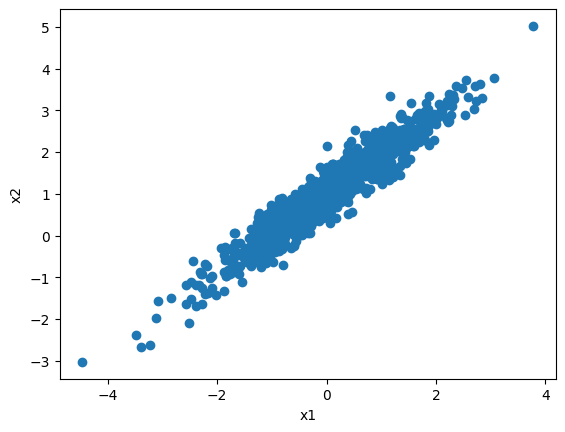

In [11]:
#### plot data
plt.scatter(data[:,0], data[:,1])
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

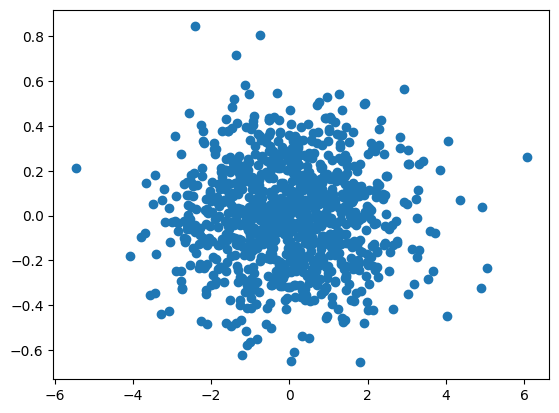

In [12]:
### perform PCA
### generate PCA model
pca_Q4 = PCA(n_components=2)

### fit PCA model with data
pca_Q4.fit(data)

### transform data with fitted PCA model
scores = pca_Q4.transform(data)
plt.scatter(scores[:,0], scores[:,1])
plt.show()

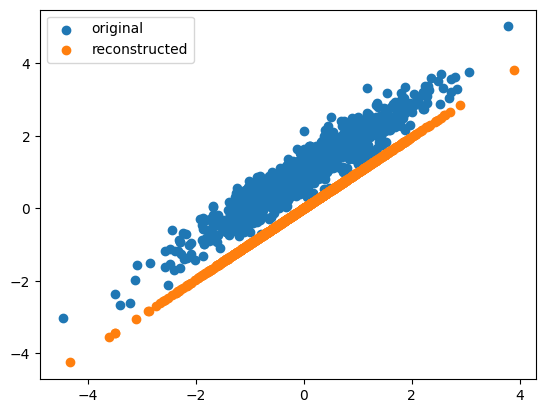

In [13]:
### reconstruct data with the first principal component
data_rec = np.matmul(scores[:,0][:, np.newaxis], pca_Q4.components_[0,:][np.newaxis,:])
plt.scatter(data[:,0], data[:,1], label='original')
plt.scatter(data_rec[:,0], data_rec[:,1], label='reconstructed')
plt.legend()
plt.show()

In [14]:
centers = np.mean(data, axis=0)
centers

array([0.03896806, 1.04408827])

In [15]:
### recover from centering
data_rec = data_rec + centers

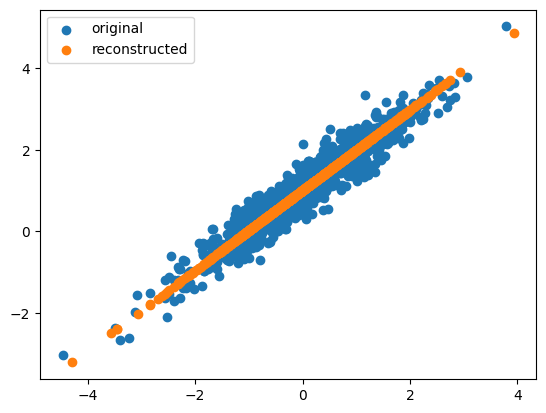

In [16]:
plt.scatter(data[:,0], data[:,1], label='original')
plt.scatter(data_rec[:,0], data_rec[:,1], label='reconstructed')
plt.legend()
plt.show()

# Q5

In [17]:
### load spectral data
spec = pd.read_csv('example_spec.csv', header=None)
spec

,0,1,2,3,4,5,6,7,8,9,...,1366,1367,1368,1369,1370,1371,1372,1373,1374,1375
0,400.000000,402.000000,404.000000,406.000000,408.000000,410.000000,412.000000,414.000000,416.000000,418.000000,...,3132.000000,3134.000000,3136.000000,3138.000000,3140.000000,3142.000000,3144.000000,3146.000000,3148.000000,3150.000000
1,80.409758,82.525749,70.133355,66.762569,76.588555,81.967791,79.486085,71.199797,62.355309,58.735971,...,8.660097,5.175334,8.597552,10.262741,9.982491,10.334204,9.371966,16.830934,24.366608,19.967173
2,77.216561,62.376232,58.634579,67.512361,80.244789,79.185585,66.275337,49.969002,36.839971,30.930802,...,16.492064,5.287952,8.031540,6.872706,9.833553,14.837850,-2.955869,-1.679584,12.059411,20.143331
3,74.633856,79.575896,72.125330,60.096492,50.503123,47.322154,49.015793,51.900495,49.847033,38.682827,...,7.359474,-12.905309,6.838368,17.632250,5.059827,7.640288,4.726514,5.324807,16.674430,29.341040
4,77.498622,71.306948,85.262589,83.609745,66.975961,70.062134,69.470127,36.657058,9.672315,30.919074,...,24.755072,0.878504,-3.171191,12.539897,30.154807,30.821919,10.936996,7.905039,13.209277,11.792370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,133.121700,125.423989,134.936621,137.801126,120.817304,90.347437,77.913085,109.294777,145.325251,140.940285,...,1.810858,-2.445955,2.254883,0.689670,-2.996327,6.643203,20.930579,6.374586,-9.671725,-10.236983
97,89.387293,79.080027,61.056192,51.778569,53.349280,50.540696,39.153420,20.822223,6.335359,6.566209,...,17.724735,14.791020,13.692711,6.451921,3.124320,10.047654,14.466106,13.862040,5.935683,2.091197
98,62.912643,55.230136,47.776575,58.476725,79.586173,77.035613,58.505852,44.106047,41.144327,49.485840,...,20.368072,30.955161,18.905626,7.022299,5.282636,10.749624,20.061126,12.168057,11.047212,14.458266
99,43.884806,45.646617,52.440729,47.428118,34.066524,28.316856,27.991125,28.031418,27.240930,25.572357,...,14.049790,10.690016,7.529614,9.896679,10.055967,6.276745,12.762249,11.094414,7.370803,7.726233


In [18]:
wn = spec.iloc[0].values
wn

array([ 400.,  402.,  404., ..., 3146., 3148., 3150.])

In [19]:
spec = spec.iloc[1:].values
spec

array([[80.4097584 , 82.52574942, 70.13335502, ..., 16.83093444,
        24.36660774, 19.96717345],
       [77.21656144, 62.37623171, 58.63457924, ..., -1.67958376,
        12.05941064, 20.14333079],
       [74.633856  , 79.57589576, 72.12533006, ...,  5.32480713,
        16.67442967, 29.34104005],
       ...,
       [62.91264307, 55.23013626, 47.77657451, ..., 12.16805671,
        11.04721166, 14.45826562],
       [43.88480622, 45.64661724, 52.44072919, ..., 11.09441428,
         7.3708034 ,  7.72623332],
       [68.99239535, 72.86187186, 71.88650847, ...,  0.64158977,
        -1.38670688,  6.92096799]])

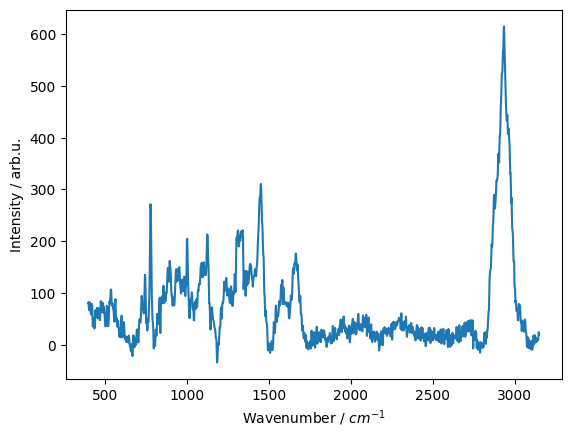

In [20]:
plt.plot(wn, spec[0,])
plt.xlabel('Wavenumber / $cm^{-1}$')
plt.ylabel('Intensity / arb.u.')
plt.show()

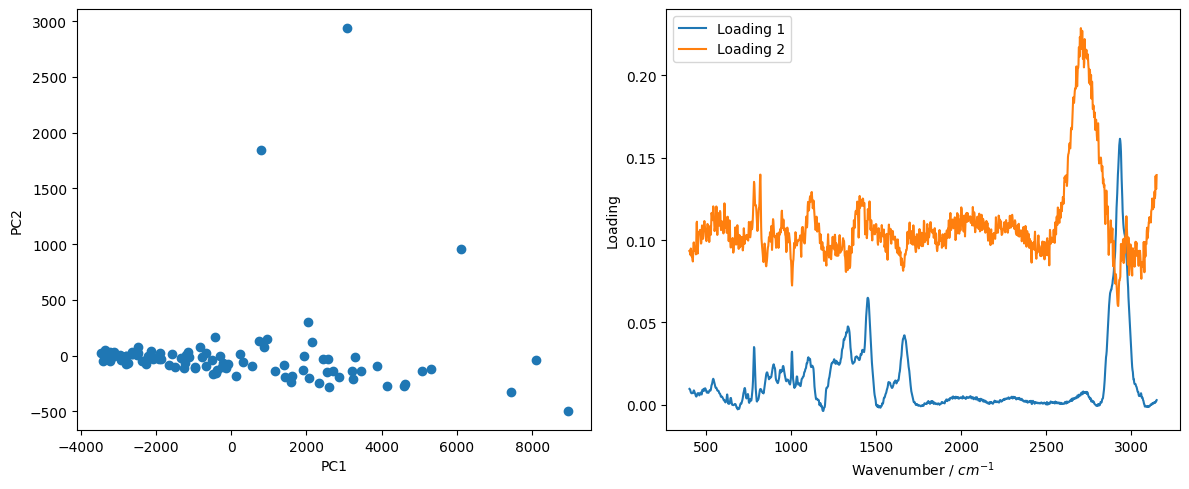

In [21]:
### perform PCA and reconstruct
pca_Q5 = PCA(n_components=10)
pca_Q5.fit(spec)
scores = pca_Q5.transform(spec)
loadings = pca_Q5.components_

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(scores[:,0], scores[:,1])
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')

ax[1].plot(wn, loadings[0, :], label='Loading 1')
ax[1].plot(wn, loadings[1, :]+0.1, label='Loading 2')
ax[1].set_xlabel('Wavenumber / $cm^{-1}$')
ax[1].set_ylabel('Loading')
ax[1].legend()

plt.tight_layout()
plt.show()

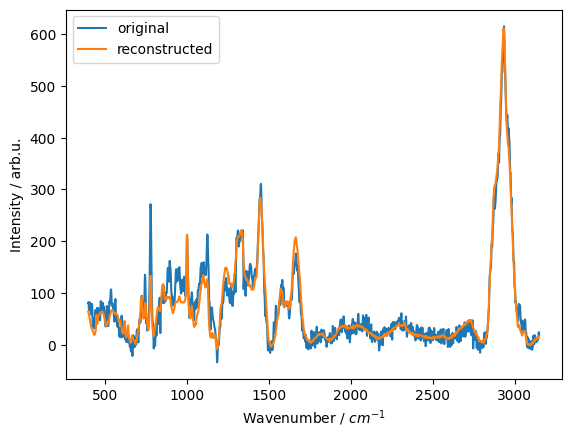

In [22]:
centers = np.mean(spec, axis=0)

### reconstruction with 2 components
n_comp = 2
spec_rec = np.matmul(scores[:, :n_comp], loadings[:n_comp, :]) + centers
plt.plot(wn, spec[0,], label='original')
plt.plot(wn, spec_rec[0,], label='reconstructed')
plt.xlabel('Wavenumber / $cm^{-1}$')
plt.ylabel('Intensity / arb.u.')
plt.legend()
plt.show()

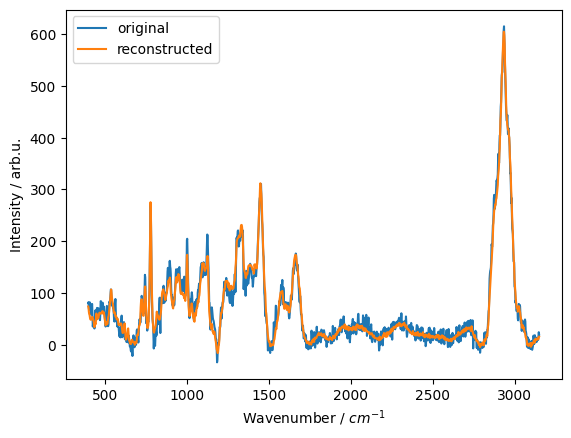

In [23]:
### reconstruction with 3 components
n_comp = 3
spec_rec = np.matmul(scores[:, :n_comp], loadings[:n_comp, :]) + centers
plt.plot(wn, spec[0,], label='original')
plt.plot(wn, spec_rec[0,], label='reconstructed')
plt.xlabel('Wavenumber / $cm^{-1}$')
plt.ylabel('Intensity / arb.u.')
plt.legend()
plt.show()

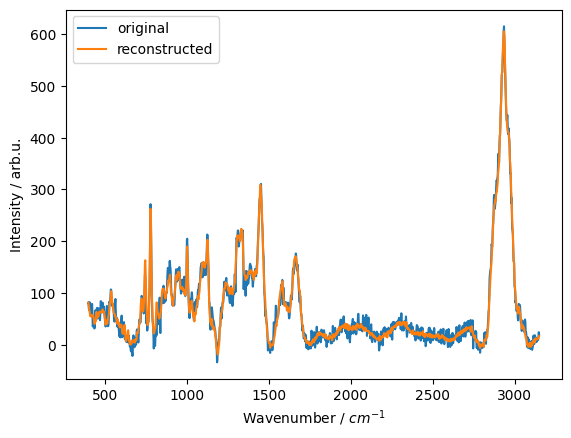

In [24]:
### reconstruction with 5 components
n_comp = 5
spec_rec = np.matmul(scores[:, :n_comp], loadings[:n_comp, :]) + centers
plt.plot(wn, spec[0,], label='original')
plt.plot(wn, spec_rec[0,], label='reconstructed')
plt.xlabel('Wavenumber / $cm^{-1}$')
plt.ylabel('Intensity / arb.u.')
plt.legend()
plt.show()